# **Análise de Sentimentos de Avaliações de Clientes com NLP e Machine Learning**

## **Problema**

Empresas recebem centenas ou milhares de avaliações de clientes. Ler tudo manualmente é demorado e dificulta identificar rapidamente:

* o que os clientes estão elogiando;
* quais problemas estão aparecendo;
* qual é a percepção geral dos clientes;
* quais avaliações precisam de atenção.

## **Proposta**

Desenvolver um pequeno pipeline de NLP capaz de:

> receber avaliações reais → processar os textos → identificar o sentimento → gerar métricas e visualizações.

## **Contexto**

As avaliações de clientes representam uma importante fonte de informação para empresas de e-commerce. Entretanto, quando existe um grande volume de avaliações, analisar manualmente cada comentário pode ser uma tarefa demorada.

Neste projeto, será desenvolvido um modelo de Processamento de Linguagem Natural (NLP) capaz de classificar automaticamente avaliações de clientes em diferentes categorias de sentimento.

## **🎯 Objetivo**

Utilizar técnicas de NLP e Machine Learning para:

analisar avaliações reais de clientes;
realizar o pré-processamento dos textos;
transformar textos em representações numéricas utilizando TF-IDF;
treinar modelos de classificação;
comparar o desempenho dos modelos;
identificar padrões nas avaliações;
extrair possíveis insights relacionados à experiência do cliente.
📚 Dataset

Será utilizado o B2W-Reviews01, um corpus público de avaliações de produtos de e-commerce em português brasileiro.

O conjunto possui mais de 130 mil avaliações coletadas da Americanas.com e contém informações como texto da avaliação, nota de 1 a 5 estrelas, recomendação do produto, categoria e dados do avaliador.

Fonte: B2W-Reviews01 — Americanas Tech.



## **Estrutura do Projeto**

1. Contexto e objetivo
2. Importação das bibliotecas
3. Carregamento do dataset
4. Conhecendo os dados
5. Análise exploratória
6. Criação da variável sentimento
7. Pré-processamento
8. Análise das palavras
9. Separação treino/teste
10. TF-IDF
11. Naive Bayes
12. Logistic Regression
13. Comparação
14. Matriz de confusão
15. Novas avaliações
16. Insights de negócio
17. Conclusão

In [43]:
# 2.Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
import pandas as pd

df = pd.read_csv("/content/B2W-Reviews01.csv")

df.head()

/tmp/ipykernel_1505/1123641088.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/B2W-Reviews01.csv")


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-01-01 00:11:28,d0fb1ca69422530334178f5c8624aa7a99da47907c44de...,132532965,Notebook Asus Vivobook Max X541NA-GO472T Intel...,NaN,Informática,Notebook,Bom,4.0,Yes,Estou contente com a compra entrega rápida o ú...,1958.0,F,RJ
1,2018-01-01 00:13:48,014d6dc5a10aed1ff1e6f349fb2b059a2d3de511c7538a...,22562178,Copo Acrílico Com Canudo 500ml Rocie,NaN,Utilidades Domésticas,"Copos, Taças e Canecas","Preço imbatível, ótima qualidade",4.0,Yes,"Por apenas R$1994.20,eu consegui comprar esse ...",1996.0,M,SC
2,2018-01-01 00:26:02,44f2c8edd93471926fff601274b8b2b5c4824e386ae4f2...,113022329,Panela de Pressão Elétrica Philips Walita Dail...,philips walita,Eletroportáteis,Panela Elétrica,ATENDE TODAS AS EXPECTATIVA.,4.0,Yes,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,1984.0,M,SP
3,2018-01-01 00:35:54,ce741665c1764ab2d77539e18d0e4f66dde6213c9f0863...,113851581,Betoneira Columbus - Roma Brinquedos,roma jensen,Brinquedos,Veículos de Brinquedo,presente mais que desejado,4.0,Yes,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,1985.0,F,SP
4,2018-01-01 01:00:28,7d7b6b18dda804a897359276cef0ca252f9932bf4b5c8e...,131788803,"Smart TV LED 43"" LG 43UJ6525 Ultra HD 4K com C...",lg,TV e Home Theater,TV,"Sem duvidas, excelente",5.0,Yes,"A entrega foi no prazo, as americanas estão de...",1994.0,M,MG


In [5]:
# 4.Conhecendo os dados

# 4.1 Verificando a quantidade de linhas e colunas
df.shape

(115150, 14)

In [6]:
# 4.2 Visualizando as colunas
df.columns

Index(['submission_date', 'reviewer_id', 'product_id', 'product_name',
       'product_brand', 'site_category_lv1', 'site_category_lv2',
       'review_title', 'overall_rating', 'recommend_to_a_friend',
       'review_text', 'reviewer_birth_year', 'reviewer_gender',
       'reviewer_state'],
      dtype='object')

In [8]:
# 4.3.Visualizando algumas avaliações
df[[
    "review_title",
    "review_text",
    "overall_rating",
    "recommend_to_a_friend"
]].head(10)

,review_title,review_text,overall_rating,recommend_to_a_friend
0,Bom,Estou contente com a compra entrega rápida o ú...,4.0,Yes
1,"Preço imbatível, ótima qualidade","Por apenas R$1994.20,eu consegui comprar esse ...",4.0,Yes
2,ATENDE TODAS AS EXPECTATIVA.,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,4.0,Yes
3,presente mais que desejado,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,4.0,Yes
4,"Sem duvidas, excelente","A entrega foi no prazo, as americanas estão de...",5.0,Yes
5,Produto imperdível,"Excelente produto, por fora em material acríli...",5.0,Yes
6,ótimo,"produto mto bom, com essa garrafinha vc pode a...",5.0,Yes
7,Gostei bastante do produto,Produto excelente qualidade boa câmera desenvo...,4.0,Yes
8,Gostei do produto,O barulho e minimo e o vento é bem forte na ve...,5.0,Yes
9,NÃO RECEBI O PRODUTO,MEU PRODUTO NAO FOI ENTREGUE E A AMERICANAS ES...,1.0,No


In [9]:
# 5.Verificando dados ausentes por coluna
df.isnull().sum()

,0
submission_date,0
reviewer_id,0
product_id,1
product_name,60
product_brand,78357
site_category_lv1,6
site_category_lv2,3378
review_title,253
overall_rating,1
recommend_to_a_friend,19


In [10]:
# 6.Verificando as notas (1 a 5 estrelas)
df["overall_rating"].value_counts().sort_index()

,count
overall_rating,
1.0,23346
2.0,7182
3.0,14183
4.0,28328
5.0,42110


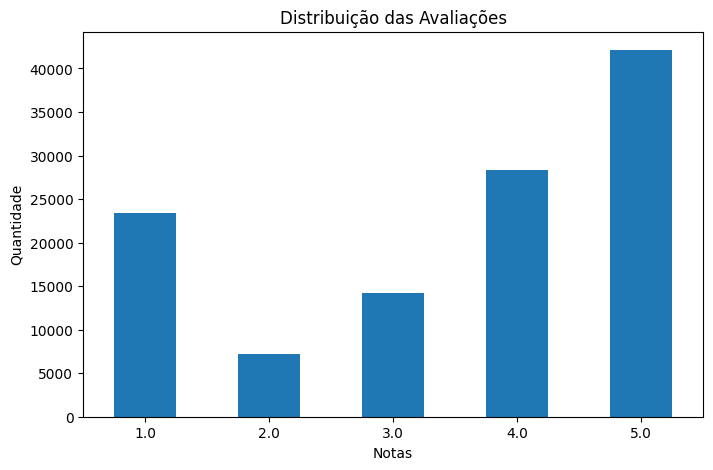

In [11]:
# 7.Plotando o primeiro gráfico
df["overall_rating"].value_counts().sort_index().plot(kind="bar",figsize=(8,5))

plt.title("Distribuição das Avaliações")
plt.xlabel("Notas")
plt.ylabel("Quantidade")
plt.xticks(rotation=0)

plt.show()

In [12]:
# 7.1.Criando o nosso sentimento (1 e 2 -> negativo, 3 -> neutro, 4 e 5 -> positivo)

# Removendo avaliações sem textou ou sem nota
df = df.dropna(subset=["review_text","overall_rating"]).copy()

# Garantindo que a nota seja numérica
df["overall_rating"] = pd.to_numeric(
    df["overall_rating"],
    errors="coerce"
)

# Removendo novamente possíveis notas inválidas
df = df.dropna(subset=["overall_rating"])

In [13]:
# 7.2.Criando função classificadora de sentimento pela nota
def classificar_sentimento(nota):
  if nota <= 2:
    return "negativo"
  elif nota == 3:
    return "neutro"
  else:
    return "positivo"

df["sentimento"] = df["overall_rating"].apply(classificar_sentimento)

df["sentimento"].value_counts()

,count
sentimento,
positivo,69581
negativo,28862
neutro,13921


<Axes: title={'center': 'Distribuição dos sentimentos'}, xlabel='sentimento'>

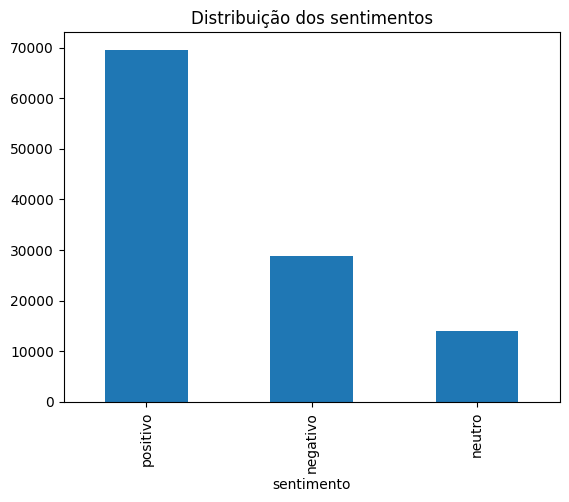

In [15]:
# 7.3.Verificando a distribuição dos sentimentos
df["sentimento"].value_counts().plot(
    kind="bar",
    title="Distribuição dos sentimentos"
)

In [16]:
# 8.Pré-processamento dos textos
import re
import unicodedata

def limpar_texto(texto):
  # Garantir que o valor seja texto
  texto = str(texto)

  # Converter para letras minúsculas
  texto = texto.lower()

  # Remover acentos
  texto = unicodedata.normalize("NFKD", texto)
  texto = texto.encode("ascii","ignore").decode("utf-8")

  # Remover pontuação e caracteres especiais
  texto = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", texto)

  # Remover espaços extras
  texto = re.sub(r"\s+", " ", texto).strip()

  return texto

In [17]:
# 8.1.Testando antes de aplicar no dataset inteiro
texto_teste = "Produto ÓTIMO!!! 😍 Chegou rápido, recomendo!!!"

print(limpar_texto(texto_teste))

produto otimo chegou rapido recomendo


In [18]:
# 8.2.Aplicando ao Dataset
df["review_text_limpo"] = df["review_text"].apply(limpar_texto)

# Visualizando alguns exemplos após aplicar
df[["review_text", "review_text_limpo"]].head(10)

,review_text,review_text_limpo
0,Estou contente com a compra entrega rápida o ú...,estou contente com a compra entrega rapida o u...
1,"Por apenas R$1994.20,eu consegui comprar esse ...",por apenas r eu consegui comprar esse lindo co...
2,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,supera em agilidade e praticidade outras panel...
3,MEU FILHO AMOU! PARECE DE VERDADE COM TANTOS D...,meu filho amou parece de verdade com tantos de...
4,"A entrega foi no prazo, as americanas estão de...",a entrega foi no prazo as americanas estao de ...
5,"Excelente produto, por fora em material acríli...",excelente produto por fora em material acrilic...
6,"produto mto bom, com essa garrafinha vc pode a...",produto mto bom com essa garrafinha vc pode at...
7,Produto excelente qualidade boa câmera desenvo...,produto excelente qualidade boa camera desenvo...
8,O barulho e minimo e o vento é bem forte na ve...,o barulho e minimo e o vento e bem forte na ve...
9,MEU PRODUTO NAO FOI ENTREGUE E A AMERICANAS ES...,meu produto nao foi entregue e a americanas es...


In [22]:
# 8.3.Verificando se algum texto ficou vazio
(df["review_text_limpo"].str.len() == 0).sum()

df = df[df["review_text_limpo"].str.len() > 0].copy()

In [24]:
# 9.Analisando as palavras mais frequentes
from collections import Counter

# 9.1.Juntando todos os textos
palavras = " ".join(df["review_text_limpo"]).split()

# 9.2.Contando as palavars
contagem_palavras = Counter(palavras)
contagem_palavras.most_common(20)

[('e', 131170),
 ('o', 89068),
 ('a', 75854),
 ('de', 73191),
 ('produto', 61998),
 ('nao', 58792),
 ('que', 53065),
 ('muito', 45632),
 ('do', 36233),
 ('com', 35214),
 ('para', 28176),
 ('um', 27958),
 ('bom', 22839),
 ('recomendo', 21759),
 ('da', 20897),
 ('entrega', 20279),
 ('no', 19023),
 ('em', 18843),
 ('mas', 16170),
 ('na', 16066)]

In [28]:
# 10.Separando em treino e teste
X = df["review_text_limpo"]

y = df["sentimento"]

# 10.1.Separando em treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 10.2.Conferindo a divisão
print("Treinamento: ", len(X_treino))
print("Teste: ", len(X_teste))

# 10.3.Verificando as proporções dos sentimentos em cada divisão
print("\nDistribuição no treinamento:")
print(y_treino.value_counts(normalize=True))

print("\nDistribuição no teste:")
print(y_teste.value_counts(normalize=True))

Treinamento:  89828
Teste:  22457

Distribuição no treinamento:
sentimento
positivo    0.619161
negativo    0.256991
neutro      0.123848
Name: proportion, dtype: float64

Distribuição no teste:
sentimento
positivo    0.619139
negativo    0.257025
neutro      0.123837
Name: proportion, dtype: float64


In [29]:
# 11. Transformando as palavras em números usando o TF-IDF
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

# 11.1.Treinando o TF-IDF
X_treino_tfidf = tfidf.fit_transform(X_treino)
X_teste_tfidf = tfidf.transform(X_teste)

# 11.2.Verificando o tamanho da matriz
print("Matriz de Treino: ", X_treino_tfidf.shape)
print("Matriz de Teste: ", X_teste_tfidf.shape)



Matriz de Treino:  (89828, 10000)
Matriz de Teste:  (22457, 10000)


In [30]:
# 12.Usando o Naive Bayes
modelo_nb = MultinomialNB()

# 12.1.Treinando o modelo
modelo_nb.fit(X_treino_tfidf, y_treino)

# 12.2.Fazendo previsões
y_pred_nb = modelo_nb.predict(X_teste_tfidf)

# 12.3.Olhando algumas previsões
for texto, real, previsto in zip(
    X_teste.head(10),
    y_teste.head(10),
    y_pred_nb[:10]
):

  print(f"Texto: {texto}")
  print(f"Real: {real}")
  print(f"Previsto: {previsto}")
  print("-" * 80)


Texto: e um produto de entrada da marca simples com carcaca de plastico e apenas gb de ram em alguns raros momentos apresenta lentidao para abrir alguns app mas nada que atrapalhe o manueio do aparelho recomendo como excelente pelo custo x beneficio do smartphone cumpre o que promete como camera tela de pol botoes funcionais brilho de tela android etc e um bom aparelho
Real: positivo
Previsto: positivo
--------------------------------------------------------------------------------
Texto: nada a reclamar do produto bonito funcional e atende a tudo que prometeu ate agora qualidade do som e otimo apesar de ter lido em alguns lugares que seria ruim recomendo
Real: positivo
Previsto: positivo
--------------------------------------------------------------------------------
Texto: nao recomendo produto nao e original estou fazendo a devolucao pois na propaganda falam q e o produto original quero o produto original
Real: negativo
Previsto: negativo
--------------------------------------------

In [33]:
# 12.4.Avaliando o modelo
accuracy_nb = accuracy_score(y_teste, y_pred_nb)

print("Acurácia:", accuracy_nb)

print("\n",classification_report(y_teste, y_pred_nb))

Acurácia: 0.8238411185821792

               precision    recall  f1-score   support

    negativo       0.79      0.88      0.83      5772
      neutro       0.45      0.20      0.28      2781
    positivo       0.87      0.92      0.90     13904

    accuracy                           0.82     22457
   macro avg       0.70      0.67      0.67     22457
weighted avg       0.80      0.82      0.80     22457



In [36]:
# 12.5.Guardando os resultados o modelo Naive Bayes
resultados = {
    "Naive Bayes": {
        "Acurácia": accuracy_nb
    }
}

resultados

{'Naive Bayes': {'Acurácia': 0.8238411185821792}}

In [40]:
# 13. Treinando outro modelo (Regressão Logística)
modelo_lr = LogisticRegression(max_iter=1000)

# 13.1.Treinando o modelo novo
modelo_lr.fit(X_treino_tfidf, y_treino)

# 13.2.Fazendo previsões com o novo modelo
y_pred_lr = modelo_lr.predict(X_teste_tfidf)

# 13.3.Avaliando o novo modelo
accuracy_lr = accuracy_score(y_teste, y_pred_lr)

print("Acurácia:", accuracy_lr)
print()
print(classification_report(y_teste, y_pred_lr))

Acurácia: 0.8420537026316961

              precision    recall  f1-score   support

    negativo       0.84      0.90      0.87      5772
      neutro       0.51      0.22      0.31      2781
    positivo       0.87      0.94      0.90     13904

    accuracy                           0.84     22457
   macro avg       0.74      0.69      0.69     22457
weighted avg       0.82      0.84      0.82     22457



In [41]:
# 13.4. Adicionando os novos resultados
resultados["Regressão Logística"] = {
    "Acurácia": accuracy_lr
}

resultados

{'Naive Bayes': {'Acurácia': 0.8238411185821792},
 'Regressão Logística': {'Acurácia': 0.8420537026316961}}

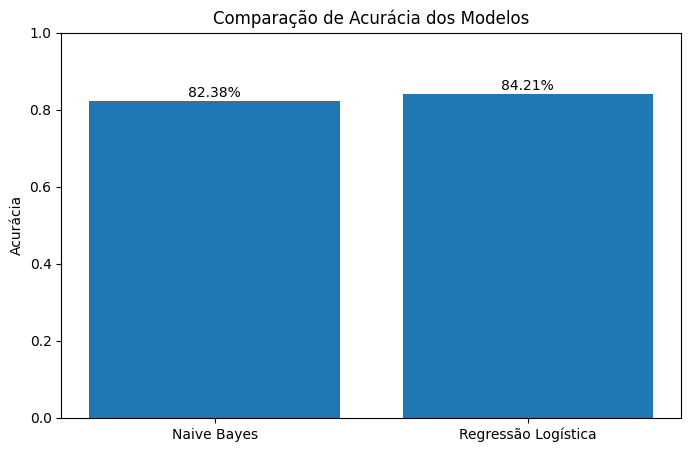

In [42]:
# 13.5.Comparando os modelos visualmente
modelos = ["Naive Bayes", "Regressão Logística"]
acuracias = [accuracy_nb, accuracy_lr]

plt.figure(figsize=(8,5))

plt.bar(modelos, acuracias)

plt.title("Comparação de Acurácia dos Modelos")
plt.ylabel("Acurácia")
plt.ylim(0,1)

for i, valor in enumerate(acuracias):
    plt.text(
        i,
        valor + 0.01,
        f"{valor:.2%}",
        ha="center"
    )

plt.show()

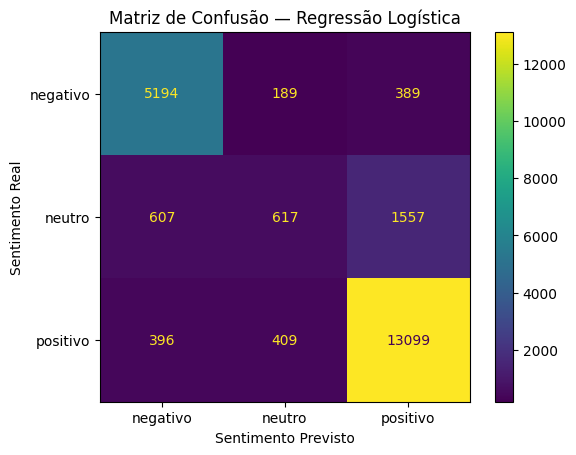

In [47]:
# 14.Matrix de Confusão da Regressão Linear
cm = confusion_matrix(y_teste, y_pred_lr, labels=["negativo", "neutro", "positivo"])
cm

# 14.2.Visualizando a matriz
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negativo", "neutro", "positivo"]
)

disp.plot()

plt.title("Matriz de Confusão — Regressão Logística")
plt.ylabel("Sentimento Real")
plt.xlabel("Sentimento Previsto")
plt.show()

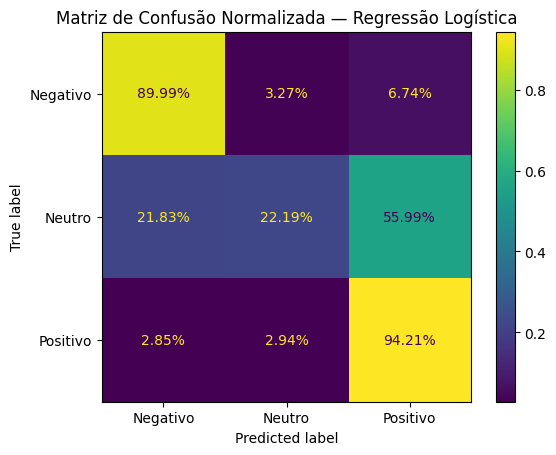

In [49]:
# 14.3.Criando uma matriz normalizada
cm_normalizada = confusion_matrix(
    y_teste,
    y_pred_lr,
    labels=["negativo", "neutro", "positivo"],
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalizada,
    display_labels=["Negativo", "Neutro", "Positivo"]
)

disp.plot(values_format=".2%")

plt.title("Matriz de Confusão Normalizada — Regressão Logística")
plt.show()

In [54]:
# 15. Testando novas avaliações no modelo

# 15.1.Criando novas avaliações
novas_avaliacoes = [
    "O produto chegou muito rápido e a qualidade é excelente. Adorei!",
    "O produto apresentou defeito e parou de funcionar depois de poucos dias.",
    "O produto chegou dentro do prazo, mas a qualidade é razoável.",
    "Gostei bastante da compra, recomendo para outras pessoas.",
    "Não gostei do produto, veio diferente do que estava anunciado."

]

# 15.2.Aplicando o mesmo pré-processamento
novas_avaliacoes_limpo = [
    limpar_texto(texto)
    for texto in novas_avaliacoes
]

# 15.3.Transformando em TF-IDF
novas_avaliacoes_tfidf = tfidf.transform(
    novas_avaliacoes_limpo
)

# 15.4.Fazendo as previsões das novas avaliações
previsoes = modelo_lr.predict(novas_avaliacoes_tfidf)

for texto, sentimento in zip(novas_avaliacoes, previsoes):
    print(f"Texto: {texto}")
    print(f"Sentimento previsto: {sentimento}")
    print("-" * 80)

Texto: O produto chegou muito rápido e a qualidade é excelente. Adorei!
Sentimento previsto: positivo
--------------------------------------------------------------------------------
Texto: O produto apresentou defeito e parou de funcionar depois de poucos dias.
Sentimento previsto: negativo
--------------------------------------------------------------------------------
Texto: O produto chegou dentro do prazo, mas a qualidade é razoável.
Sentimento previsto: neutro
--------------------------------------------------------------------------------
Texto: Gostei bastante da compra, recomendo para outras pessoas.
Sentimento previsto: positivo
--------------------------------------------------------------------------------
Texto: Não gostei do produto, veio diferente do que estava anunciado.
Sentimento previsto: negativo
--------------------------------------------------------------------------------


# **Insights de Negócio**

Uma empresa de e-commerce recebe milhares de avaliações de clientes.

Ler manualmente todas elas seria demorado.

Nosso modelo usando ML e NLP permite a empresa a ter uma visão geral da percepção dos clientes sobre as avaliações

## **Insight 1: Identificar Reclamações**
Avaliações classificadas como negativas podem ser direcioandas para análise.

Por exemplo:

> "O produto chegou quebrado."

> "A entrega demorou muito."

> "O produto não corresponde ao anúncio."

A empresa poderia utilizar essas informações para identificar problemas relacionados a:

* qualidade;
* logística;
* atendimento;
* descrição dos produtos;
* fornecedores.

## **Insight 2: Identificar Pontos Positivos**

As avaliações positivas também possuem valor.

Imagine descobrir que várias avaliações mencionam:

> "entrega rápida"

ou:

> "ótima qualidade"

Isso pode indicar quais aspectos da experiência do cliente estão funcionando bem.

## **Insight 3: Monitoramento Automático**

Em vez de alguém precisar analisar manualmente milhares de avaliações.

A empresa poderia acompanhar a evolução dos sentimentos ao longo do tempo.

Por exemplo:

> "Neste mês, a quantidade de avaliações negativas aumentou 15%."

Isso poderia servir como um indicador de alerta.

## **Insight 4: Limitação com a Classe Neutra**

O modelo apresenta limitações com avaliações neutras, portante, é necessário:

* melhorar o tratamento das classes;
* testar outros algoritmos;
* experimentar diferentes parâmetros do TF-IDF;
* trabalhar melhor o português;
* aumentar exemplos da classe neutra;
* investigar técnicas de balanceamento;
* testar modelos mais avançados de NLP.

# **Conclusão**

Neste projeto foi desenvolvido um modelo de Processamento de Linguagem Natural (NLP) para classificação automática de avaliações de clientes de um e-commerce em três categorias: negativo, neutro e positivo.

Foi utilizado o dataset B2W-Reviews01, contendo avaliações reais de consumidores brasileiros. Após o tratamento dos dados, os textos foram pré-processados e transformados em representações numéricas utilizando TF-IDF.

Foram avaliados dois algoritmos de classificação: Multinomial Naive Bayes e Regressão Logística. O Naive Bayes apresentou acurácia de 82,38%, enquanto a Regressão Logística alcançou 84,21%, apresentando o melhor desempenho geral no experimento.

Apesar do bom desempenho nas classes positiva e negativa, os modelos apresentaram maior dificuldade na identificação de avaliações neutras. Na Regressão Logística, por exemplo, a classe neutra apresentou F1-score de 0,31, indicando uma oportunidade de melhoria.

Do ponto de vista de negócio, a classificação automática de sentimentos pode auxiliar empresas de e-commerce no monitoramento da satisfação dos clientes, identificação de problemas recorrentes e análise de grandes volumes de avaliações.

Como próximos passos, seria possível testar técnicas de balanceamento das classes, diferentes configurações de TF-IDF, outros algoritmos de Machine Learning e modelos mais avançados de NLP, buscando melhorar principalmente a identificação das avaliações neutras.